notebooks modified as a sign that your new imp was seen
Using device: cuda
CNN Split (70/15/15):
Train Size: 23526
Val Size: 5041
Test Size: 5042
Computed normalization mean: [0.4751874804496765, 0.3897644579410553, 0.35922226309776306]
Computed normalization std:  [0.24051280319690704, 0.21553964912891388, 0.21091507375240326]
Epoch [1/5] | Train Loss: 0.2027, Train Acc: 0.9124 | Val Loss: 0.0451, Val Acc: 0.9857
Epoch [2/5] | Train Loss: 0.0552, Train Acc: 0.9795 | Val Loss: 0.0243, Val Acc: 0.9923
Epoch [3/5] | Train Loss: 0.0254, Train Acc: 0.9914 | Val Loss: 0.0146, Val Acc: 0.9937
Epoch [4/5] | Train Loss: 0.0267, Train Acc: 0.9911 | Val Loss: 0.0131, Val Acc: 0.9950
Epoch [5/5] | Train Loss: 0.0213, Train Acc: 0.9928 | Val Loss: 0.0104, Val Acc: 0.9966


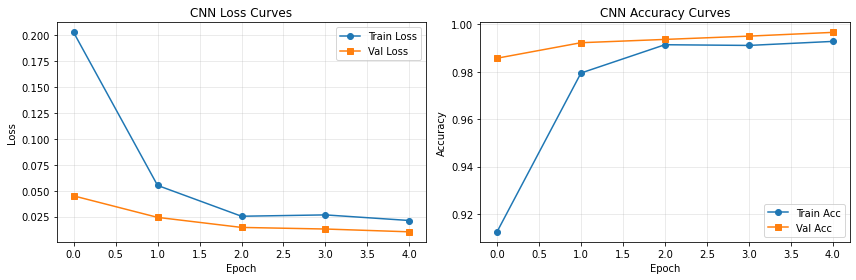

Test Accuracy:  0.9952
Precision:      0.9937
Recall:         0.9968
F1-score:       0.9952


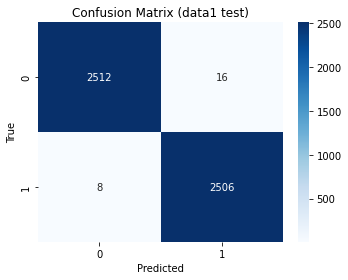

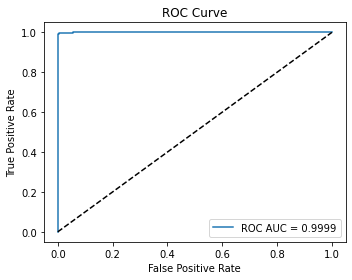

In [1]:
print("notebooks modified as a sign that your new imp was seen")
#!/usr/bin/env python
# coding: utf-8

# In[ ]:



# # Deepfake Detection System - Notebook 3
# ## CNN Classifier (Real vs Fake)
# 
# **Objective:**
# 1. Fine-tune a pre-trained **EfficientNet-B0** model for binary classification.
# 2. Utilize **CUDA** for accelerated training.
# 3. Apply **Data Augmentation** to improve generalization and mitigate bias.
# 4. Evaluate performance with accuracy, precision, recall, F1-score, and ROC/AUC.

# In[1]:


import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
DATASET_PATH = r'c:\Users\youssefsaad5\Downloads\deep_fake_project\dataset'
DATA1_PATH = os.path.join(DATASET_PATH, 'data1')
DATA2_PATH = os.path.join(DATASET_PATH, 'data2')

DATA1_TRAIN_DIR = os.path.join(DATA1_PATH, 'train')
DATA1_VAL_DIR = os.path.join(DATA1_PATH, 'val')
DATA1_TEST_DIR = os.path.join(DATA1_PATH, 'test')

DATA2_DIR = DATA2_PATH
OWN_EXTRACTED_REAL = os.path.join(DATASET_PATH, 'own_dataset_extracted', 'real')
OWN_EXTRACTED_AUG_DIR = os.path.join(DATASET_PATH, 'own_dataset_extracted_augmented')
OWN_EXTRACTED_AUG_REAL = os.path.join(OWN_EXTRACTED_AUG_DIR, 'real')


# ### 1. Data Augmentation & Loading

# In[ ]:


valid_ext = ('.png', '.jpg', '.jpeg')

def gather_images(folder):
    return sorted([f for f in glob.glob(os.path.join(folder, '*')) if f.lower().endswith(valid_ext)])

def compute_mean_std(image_paths, max_samples=1200):
    if len(image_paths) == 0:
        raise RuntimeError("No images found for mean/std computation.")

    sample_paths = image_paths[:max_samples] if len(image_paths) > max_samples else image_paths
    means, stds = [], []

    for p in sample_paths:
        img = Image.open(p).convert('RGB').resize((224, 224))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        stds.append(arr.std(axis=(0, 1)))

    mean = np.stack(means).mean(axis=0)
    std = np.stack(stds).mean(axis=0)
    std = np.clip(std, 1e-6, None)
    return mean.tolist(), std.tolist()

class CNNDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        img = Image.open(path).convert('RGB')
        label = self.labels[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# Gather ALL available data and apply a 70/15/15 split
all_real_paths = sorted(gather_images(os.path.join(DATA1_TRAIN_DIR, 'real')) + 
                        gather_images(os.path.join(DATA1_VAL_DIR, 'real')) +
                        gather_images(os.path.join(DATA1_TEST_DIR, 'real')) +
                        gather_images(os.path.join(DATA2_DIR, 'real')) +
                        gather_images(OWN_EXTRACTED_AUG_REAL))

all_fake_paths = sorted(gather_images(os.path.join(DATA1_TRAIN_DIR, 'fake')) + 
                        gather_images(os.path.join(DATA1_VAL_DIR, 'fake')) +
                        gather_images(os.path.join(DATA1_TEST_DIR, 'fake')) +
                        gather_images(os.path.join(DATA2_DIR, 'fake')))

# Ensure uniqueness
all_real_paths = list(set(all_real_paths))
all_fake_paths = list(set(all_fake_paths))

# Shuffle before splitting
rng = random.Random(42)
rng.shuffle(all_real_paths)
rng.shuffle(all_fake_paths)

def split_70_15_15(paths):
    n = len(paths)
    t_end = int(0.70 * n)
    v_end = int(0.85 * n)
    return paths[:t_end], paths[t_end:v_end], paths[v_end:]

tr_r, val_r, ts_r = split_70_15_15(all_real_paths)
tr_f, val_f, ts_f = split_70_15_15(all_fake_paths)

train_paths = tr_r + tr_f
train_labels = [0]*len(tr_r) + [1]*len(tr_f)

val_paths = val_r + val_f
val_labels = [0]*len(val_r) + [1]*len(val_f)

test_paths = ts_r + ts_f
test_labels = [0]*len(ts_r) + [1]*len(ts_f)

print(f"CNN Split (70/15/15):")
print(f"Train Size: {len(train_paths)}")
print(f"Val Size: {len(val_paths)}")
print(f"Test Size: {len(test_paths)}")

norm_mean, norm_std = compute_mean_std(train_paths, max_samples=1200)
print(f"Computed normalization mean: {norm_mean}")
print(f"Computed normalization std:  {norm_std}")

# Lowered Regularization even further: Keep only Resize and ToTensor 
# so the network has highly pure features to map against
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

train_dataset = CNNDataset(train_paths, train_labels, transform=train_transform)
val_dataset = CNNDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = CNNDataset(test_paths, test_labels, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# ### 2. Model: EfficientNet-B0

# In[ ]:


model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_features, 2)
)
model = model.to(device)
criterion = nn.CrossEntropyLoss()

# Restore standard weight_decay (0.01) to prevent overfitting
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)


# ### 3. Training Loop

# In[6]:


num_epochs = 5
patience = 2
best_val_loss = float('inf')
best_state = None
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = train_correct / train_total

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total

    scheduler.step(epoch_val_loss)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), 'cnn_efficientnet.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_loss': best_val_loss,
}, 'cnn_efficientnet_checkpoint.pth')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, marker='o', label='Train Loss')
axes[0].plot(val_losses, marker='s', label='Val Loss')
axes[0].set_title('CNN Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, marker='o', label='Train Acc')
axes[1].plot(val_accs, marker='s', label='Val Acc')
axes[1].set_title('CNN Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_learning_curves.png', dpi=150)
plt.show()


# ### 4. Comprehensive Evaluation on Test Set

# In[ ]:


model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = nn.functional.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
acc = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-score:       {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (data1 test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

